## Medical Cost Personal - Regression Model

This jupyter notebook walks through a complete machine learning workflow for predicting Charge or Cost  using the `Insurance.csv` dataset using Linear Regression models.

It covers:

- **Basic Information** — understanding the dataset's structure, size and info
- **Exploratory Data Analysis (EDA) Univariate & bivariate** — understanding the dataset's structure, distributions, and key trends
- **Data Cleaning** — handling missing values and standardizing messy categorical columns
- **Feature Engineering and Label Engineering** — simplifying and encoding categorical variables
- **Cross Validation** — deatermine reliable estimate of how your model will perform on unseen data.
- **Model Training** — comparing multiple regression algorithms
- **Model Evaluation** — using R², MSE, and MAE to identify the best-performing model
- **Hyperparameter Tuning** — Improving the model performance

In [435]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor,AdaBoostRegressor,HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [436]:
df = pd.read_csv(r'C:\Users\aoilu\Documents\Data Science Techcrush\Medical Cost Personal Datasets\insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Basic Information

In [437]:
df.shape

(1338, 7)

In [438]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [439]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [440]:
df["age"].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [441]:
df.duplicated().sum() #check if there are duplicated values


np.int64(1)

In [442]:
duplicates = df[df.duplicated()]
duplicates

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [443]:
duplicates = df[df.duplicated(keep=False)]#since both are obvious duplicates, it better to drop one to reduce noise
duplicates

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [444]:
df.value_counts().loc[lambda x: x > 1]

age  sex   bmi    children  smoker  region     charges  
19   male  30.59  0         no      northwest  1639.5631    2
Name: count, dtype: int64

In [445]:
df = df.drop_duplicates()#drop duplicate

In [446]:
duplicates = df[df.duplicated()]
df.shape

(1337, 7)

## Univariate Analysis

In [447]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [448]:
df[["age","bmi"]].describe()

,age,bmi
count,1337.000000,1337.000000
mean,39.222139,30.663452
std,14.044333,6.100468
min,18.000000,15.960000
25%,27.000000,26.290000
50%,39.000000,30.400000
75%,51.000000,34.700000
max,64.000000,53.130000


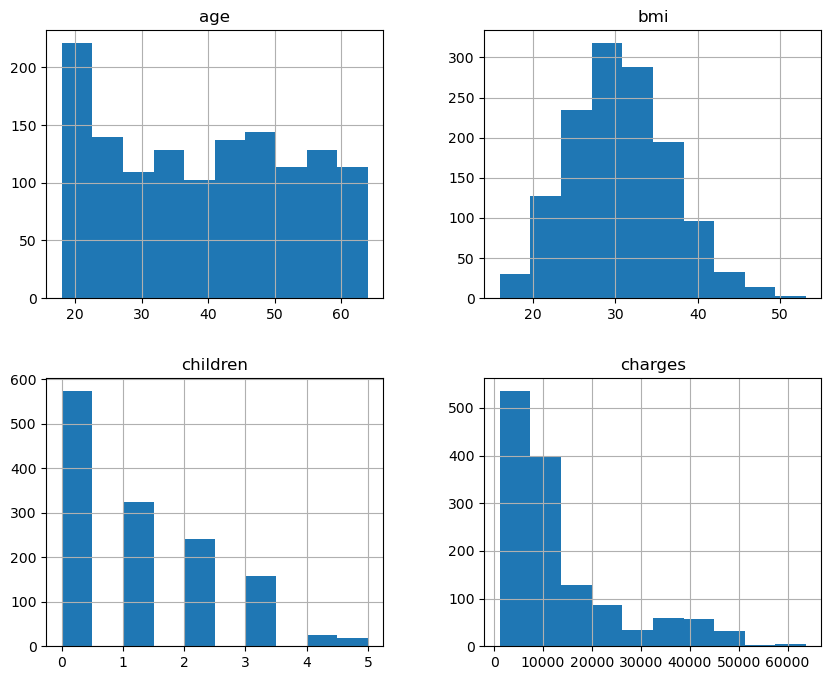

In [449]:
df.hist(figsize=(10,8))
plt.show()

In [450]:
#looking at the target itself

df["charges"].skew()

np.float64(1.5153909108403483)

<Axes: xlabel='charges', ylabel='Count'>

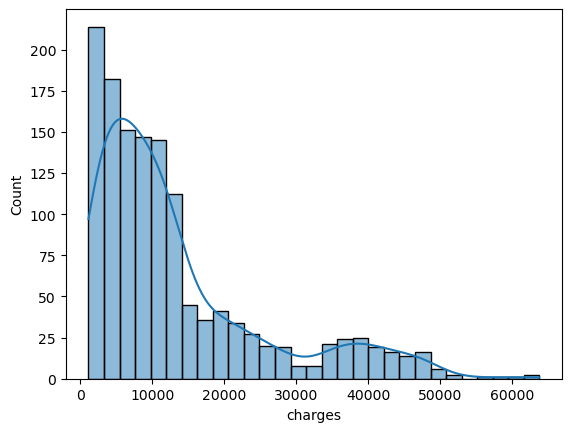

In [451]:
sns.histplot(df["charges"], kde=True)

In [452]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[df["charges"] > upper]["charges"]

print(len(outliers))

outliers_df = df[df["charges"] > upper]

outliers_df

139


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [453]:
#since there are 139 outliers and are starting above 30000, based on medical data,
#they could be aged, smokers, many children and high bmi. we wont remove them

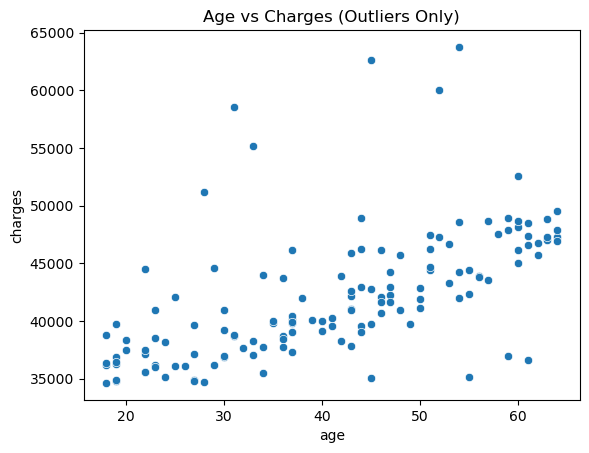

In [454]:
sns.scatterplot(
    data=outliers_df,
    x="age",
    y="charges"
)

plt.title("Age vs Charges (Outliers Only)")
plt.show()

In [455]:
df[["age", "bmi"]].agg(["mean", "median"])

,age,bmi
mean,39.222139,30.663452
median,39.000000,30.400000


In [456]:
df[["age", "bmi"]].mode()

,age,bmi
0,18,32.3


In [457]:
#categotical values

df.sex.value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [458]:
df.smoker.value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [459]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

* Its easier to say

1. ages between 18-20 access the health care most
2. male gender and non smokers visited most
3. The southeast has a significant use than other regions
4. people with 30-35 BMI has most visit as well

In [460]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


## Bivariate Analysis

In [461]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


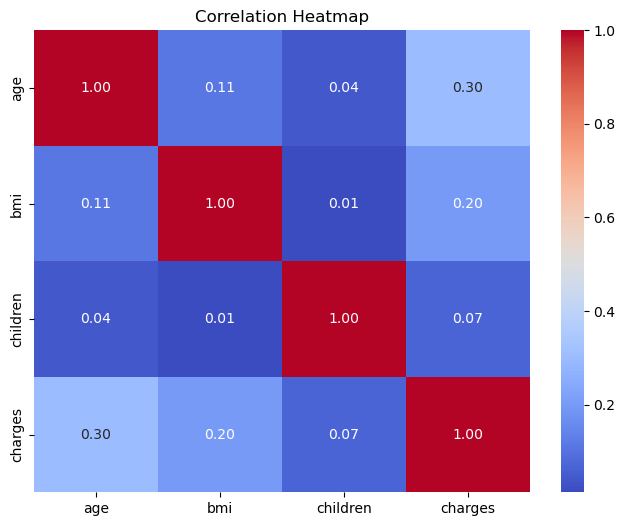

In [462]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


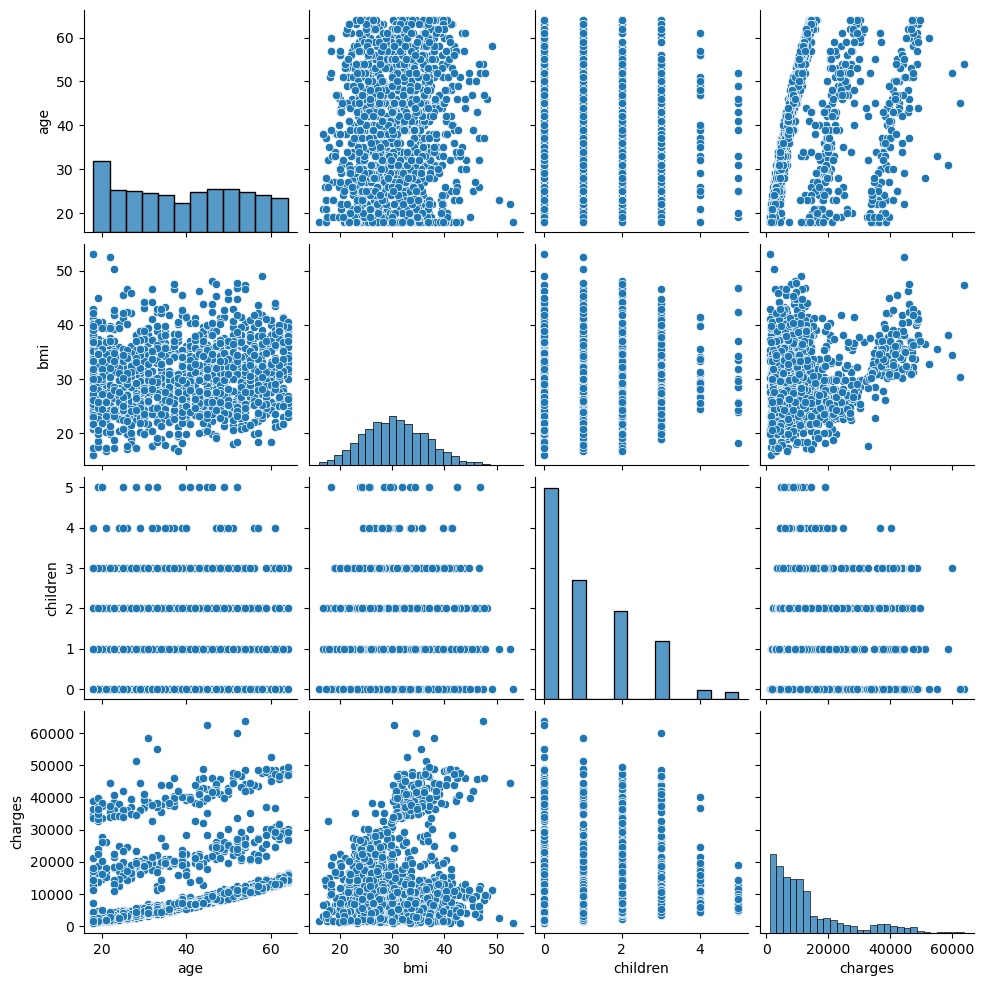

In [463]:
sns.pairplot(df)

plt.show()

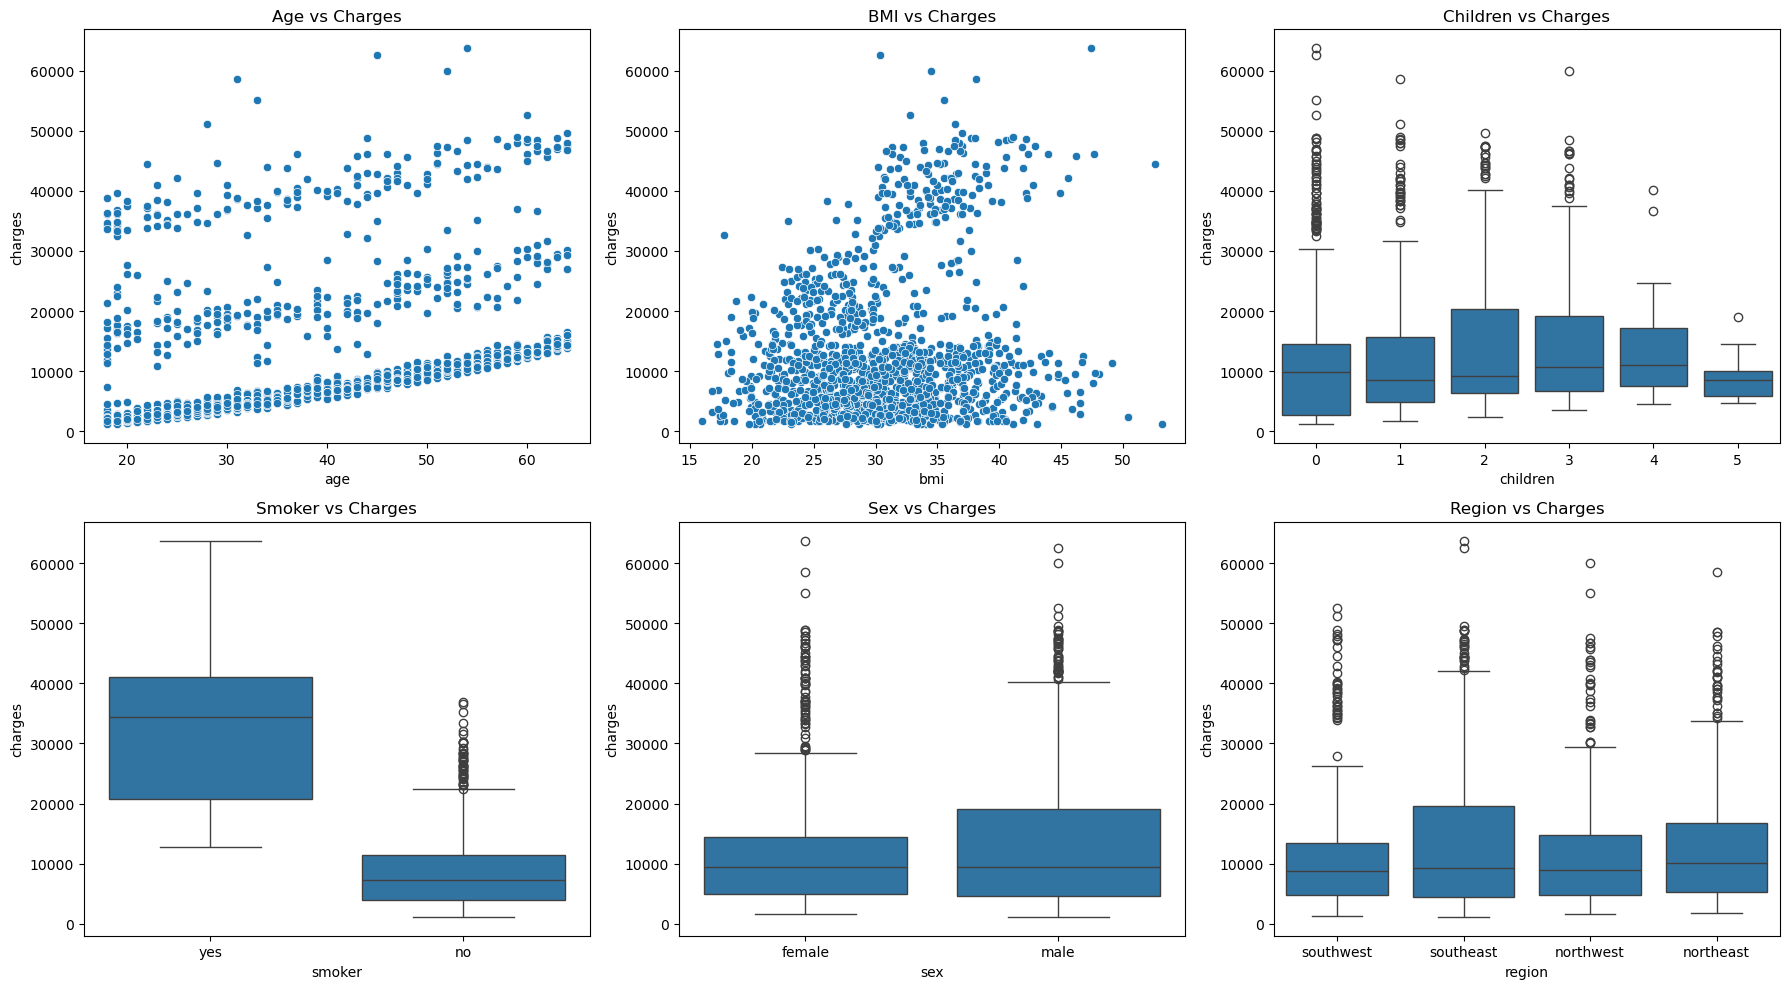

In [464]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Numerical features vs charges
sns.scatterplot(data=df, x="age", y="charges", ax=axes[0,0])
axes[0,0].set_title("Age vs Charges")

sns.scatterplot(data=df, x="bmi", y="charges", ax=axes[0,1])
axes[0,1].set_title("BMI vs Charges")

sns.boxplot(data=df, x="children", y="charges", ax=axes[0,2])
axes[0,2].set_title("Children vs Charges")


# Categorical features vs charges
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[1,0])
axes[1,0].set_title("Smoker vs Charges")

sns.boxplot(data=df, x="sex", y="charges", ax=axes[1,1])
axes[1,1].set_title("Sex vs Charges")

sns.boxplot(data=df, x="region", y="charges", ax=axes[1,2])
axes[1,2].set_title("Region vs Charges")


plt.tight_layout()
plt.show()

In [465]:
#since the label outliers also has a pattern, with the correlation shown for the age and bmi. we can explore it

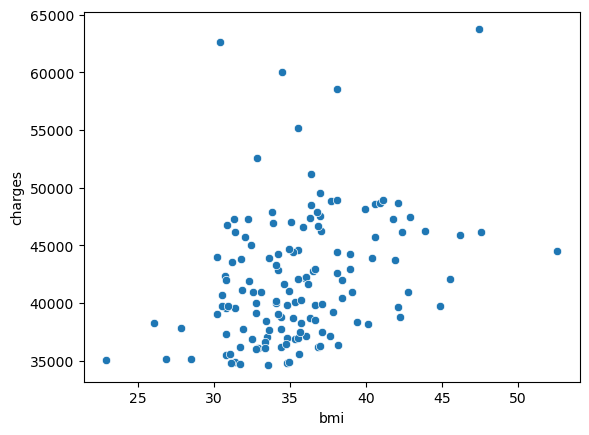

In [466]:
sns.scatterplot(
    data=outliers_df,
    x="bmi",
    y="charges"
)
plt.show()

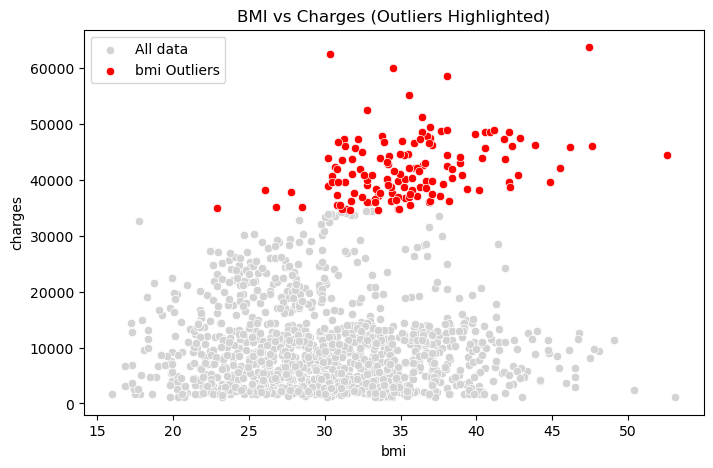

In [467]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="bmi", y="charges", color="lightgray", label="All data")
sns.scatterplot(data=outliers_df, x="bmi", y="charges", color="red", label="bmi Outliers")

plt.title("BMI vs Charges (Outliers Highlighted)")
plt.legend()
plt.show()

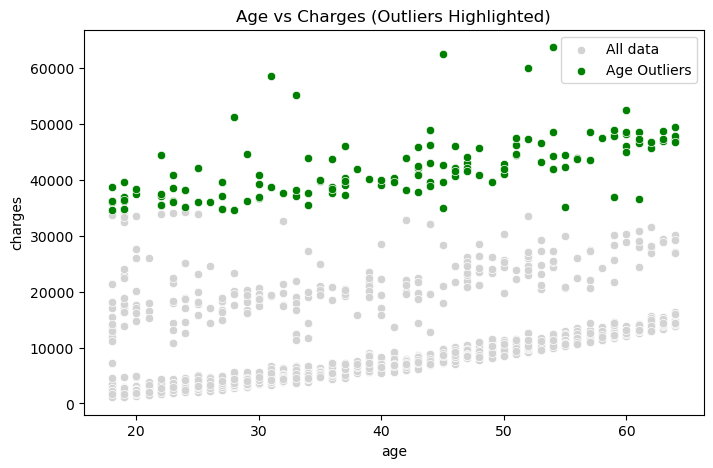

In [468]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="age", y="charges", color="lightgray", label="All data")
sns.scatterplot(data=outliers_df, x="age", y="charges", color="green", label="Age Outliers")

plt.title("Age vs Charges (Outliers Highlighted)")
plt.legend()
plt.show()

In [469]:
df.groupby("sex")["charges"].mean()

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

In [470]:
df.groupby("region")["charges"].mean()

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [471]:
df.groupby(["smoker", "sex"])["charges"].mean()

smoker  sex   
no      female     8762.297300
        male       8099.700161
yes     female    30678.996276
        male      33042.005975
Name: charges, dtype: float64

In [472]:
df.groupby("children")["charges"].mean()

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

## Label Engineering

Due to the skewness of the label(target). its good to introduce a log function to make it more symmetric

In [473]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [474]:
#due to the skewness of the label. its good to introduce a log function to make it more symmetric

In [475]:
df.charges.skew()

np.float64(1.5153909108403483)

In [476]:
df["log_charges"] = np.log(df["charges"])

In [477]:
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


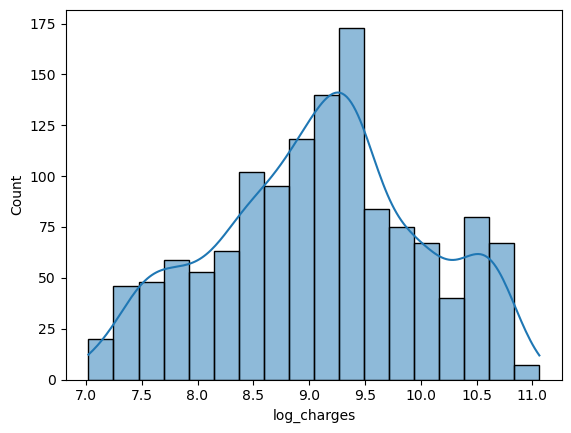

In [478]:
sns.histplot( df[ "log_charges"],kde=True)

plt.show()

#this look more uniform

In [479]:
x = df.drop(columns=["charges",'log_charges'])
y = df["charges"]
log_y = df["log_charges"]

In [480]:
x.columns 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

In [481]:
log_y

0        9.734176
1        7.453302
2        8.400538
3        9.998092
4        8.260197
          ...    
1333     9.268661
1334     7.698927
1335     7.396233
1336     7.604867
1337    10.279914
Name: log_charges, Length: 1337, dtype: float64

## Feature Encoding

1. We dont have 3rd option, either Female or male for gender , Yes or No for smoke , we can use mapping or label encoder

In [482]:
x

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [483]:
#since we dont have other option, either Female or male, Yes or No for smoke , we can use mapping or label encoder

In [484]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 73.1+ KB


In [485]:
encoder = LabelEncoder()

x["sex"] = encoder.fit_transform(x["sex"])
x["smoker"] = encoder.fit_transform(x["smoker"])

In [486]:
x

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,southwest
1,18,1,33.770,1,0,southeast
2,28,1,33.000,3,0,southeast
3,33,1,22.705,0,0,northwest
4,32,1,28.880,0,0,northwest
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest
1334,18,0,31.920,0,0,northeast
1335,18,0,36.850,0,0,southeast
1336,21,0,25.800,0,0,southwest


In [487]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int64  
 5   region    1337 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 73.1+ KB


In [488]:
#lastly, region, we will use one hot encoder

In [489]:
#we only have one categorical column = region

In [490]:
x = pd.get_dummies(x,columns=["region"], dtype=int)

In [491]:
x

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,0,1,0,0
1334,18,0,31.920,0,0,1,0,0,0
1335,18,0,36.850,0,0,0,0,1,0
1336,21,0,25.800,0,0,0,0,0,1


## Standardization 

bmi and age are in 10s and other features are in units, its better to use the Standard Scaler

In [492]:
scaler = StandardScaler()
scalerX = scaler.fit_transform(x)

scalerX

array([[-1.44041773, -1.00977099, -0.45315959, ..., -0.5655458 ,
        -0.61163774,  1.76460935],
       [-1.51164747,  0.99032355,  0.50942165, ..., -0.5655458 ,
         1.63495472, -0.56669767],
       [-0.79935006,  0.99032355,  0.3831546 , ..., -0.5655458 ,
         1.63495472, -0.56669767],
       ...,
       [-1.51164747, -1.00977099,  1.01448983, ..., -0.5655458 ,
         1.63495472, -0.56669767],
       [-1.29795825, -1.00977099, -0.79752426, ..., -0.5655458 ,
        -0.61163774,  1.76460935],
       [ 1.55123139, -1.00977099, -0.26129928, ...,  1.76820338,
        -0.61163774, -0.56669767]], shape=(1337, 9))

# Train-Test-Split



In [493]:
x_train,x_test,y_train,y_test = train_test_split(scalerX,y,test_size=0.2,random_state=93)

In [494]:
len(x_train),len(x_test),len(y_train),len(y_test)

(1069, 268, 1069, 268)

## Cross Validation

this will enable dividing the data set into  section to improve model

In [495]:
kf = KFold( n_splits=5, shuffle=True,  random_state=4)

# Comparing and Training Model 

12 Regression Models are used on the same training and test split

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. K Neighbors Regressor
5. Support Vector Regressor
6. Extra Trees Regressor
7. Gradient Boosting Regressor
8. AdaBoost Regressor
9. HistGradientBoosting Regressor
10. XGBoost Regressor
11. LightGBM Regressor
12. CatBoost Regressor


Beyond R², we also calculate **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)** for each model

## Scikit-learn Models

In [496]:
models = [LinearRegression(),DecisionTreeRegressor(),RandomForestRegressor(),KNeighborsRegressor(),SVR(), 
         ExtraTreesRegressor(),    GradientBoostingRegressor(),    AdaBoostRegressor(),    HistGradientBoostingRegressor()]

model_names = ["Linear Regression","Decision Tree Regressor","Random Forest Regressor",
               "K Neighbors Regressor","Support Vector Regressor","Extra Trees Regressor",    "Gradient Boosting Regressor",
    "AdaBoost Regressor",    "HistGradientBoosting Regressor" ]

metrics_result = []

for model, name in zip(models, model_names):
    # Cross-validation on training data
    cv_scores = cross_val_score(  model, x_train, y_train, cv=kf,scoring="r2" )

    # Train on the full training set
    model.fit(x_train, y_train)

    # Predict on the test set
    y_pred = model.predict(x_test)
    
   # Test metrics
    r2 = r2_score( y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
 
    metrics_result.append([        name,
        round(cv_scores.mean(), 4),   # Mean CV R²
        round(cv_scores.std(), 4),    # CV Standard Deviation
        round(r2, 4),                 # Test R²
        round(mse, 4),
        round(mae, 4),
        round(rmse, 4)    ])
   



## Non - Scikit-learn Models

In [497]:
models = [ XGBRegressor(),    LGBMRegressor(verbose=-1),    CatBoostRegressor(verbose=0)]

model_names = ["XGBoost Regressor", "LightGBM Regressor",  "CatBoost Regressor"]



for model, name in zip(models, model_names):
    # Cross-validation on training data
    cv_scores = cross_val_score(  model, x_train, y_train, cv=kf,scoring="r2" )

    # Train on the full training set
    model.fit(x_train, y_train)

    # Predict on the test set
    y_pred = model.predict(x_test)
    
   # Test metrics
    r2 = r2_score( y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
 
    metrics_result.append([        name,
        round(cv_scores.mean(), 4),   # Mean CV R²
        round(cv_scores.std(), 4),    # CV Standard Deviation
        round(r2, 4),                 # Test R²
        round(mse, 4),
        round(mae, 4),
        round(rmse, 4)    ])
   

# Model Performance and Metrics

1. Higher R² → explains more variance
2. Lower MAE → smaller average error 
3. Lower RMSE → fewer large mistakes

In [498]:
results_df = pd.DataFrame(  metrics_result, columns=[ "Model","CV Mean R²",  "CV Std", "Test R²", "MSE", "MAE", "RMSE"  ])

results_df = results_df.sort_values(  by="Test R²", ascending=True)

results_df = results_df.reset_index(drop=True)
results_df.index = results_df.index + 1

results_df


,Model,CV Mean R²,CV Std,Test R²,MSE,MAE,RMSE
1,Support Vector Regressor,-0.1118,0.0393,-0.0670,1.465605e+08,7893.6963,12106.2190
2,Decision Tree Regressor,0.6750,0.0855,0.7175,3.880229e+07,2816.1872,6229.1483
3,Linear Regression,0.7426,0.0193,0.7418,3.546258e+07,4083.6405,5955.0465
4,K Neighbors Regressor,0.7719,0.0201,0.7946,2.820704e+07,3209.3995,5311.0299
5,Extra Trees Regressor,0.8113,0.0283,0.8199,2.473705e+07,2618.4388,4973.6357
6,AdaBoost Regressor,0.8146,0.0162,0.8269,2.377761e+07,3730.6540,4876.2293
7,XGBoost Regressor,0.8063,0.0371,0.8374,2.233375e+07,2805.9602,4725.8592
8,Random Forest Regressor,0.8310,0.0253,0.8488,2.076375e+07,2473.2488,4556.7261
9,HistGradientBoosting Regressor,0.8267,0.0287,0.8536,2.011129e+07,2612.3898,4484.5612
10,LightGBM Regressor,0.8280,0.0267,0.8582,1.947692e+07,2542.8385,4413.2659


# Identifying the best performing model

All models by their R² score in descending order and identify the model with the **highest R²**, indicating the best predictive performance for Charges

In [499]:
best_model = sorted(metrics_result, key=lambda x: x[3], reverse=True)
print(f"Overall best model for predicting the Charges is : {best_model[0][0]}")
print(f"With a R2 score of: {best_model[0][3]}")

Overall best model for predicting the Charges is : Gradient Boosting Regressor
With a R2 score of: 0.8709


# Top 3 Models by R² Score

We extract the **top 3 models** based on R² score and display their scores as percentages for easier comparison.

In [500]:
top_three = best_model[:3]

# Separate model names and scores
top_three_models = [model[0] for model in top_three]
top_three_scores = [round(model[3], 4) for model in top_three]

# Print
# Format scores as percentages
formatted_scores = [f"{score * 100:.2f}%" for score in top_three_scores]

print(f"Top three models are {', '.join(top_three_models)},\nwith scores {formatted_scores}")


Top three models are Gradient Boosting Regressor, CatBoost Regressor, LightGBM Regressor,
with scores ['87.09%', '85.93%', '85.82%']


In [501]:
#Sckit learn models perfomed well as expected

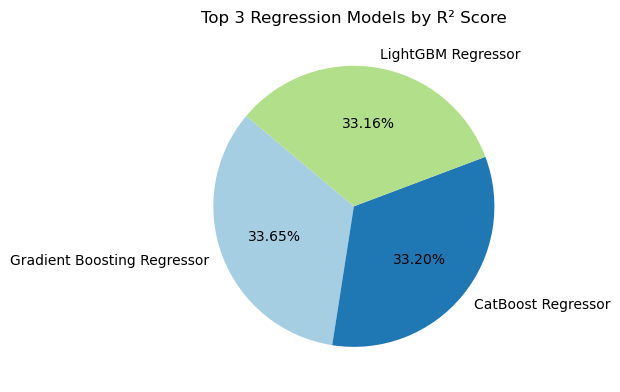

In [502]:
plt.figure(figsize=(6, 6))
plt.pie(
    top_three_scores,                      # Values
    labels=top_three_models,              # Labels
    autopct='%1.2f%%',                    # Show percentage
    startangle=140,                       # Rotate for better view
    colors=plt.cm.Paired.colors[:3]       # Optional color palette
)
plt.title('Top 3 Regression Models by R² Score')
plt.tight_layout()
plt.show()


## Label Engineering 

see if log y will perform better

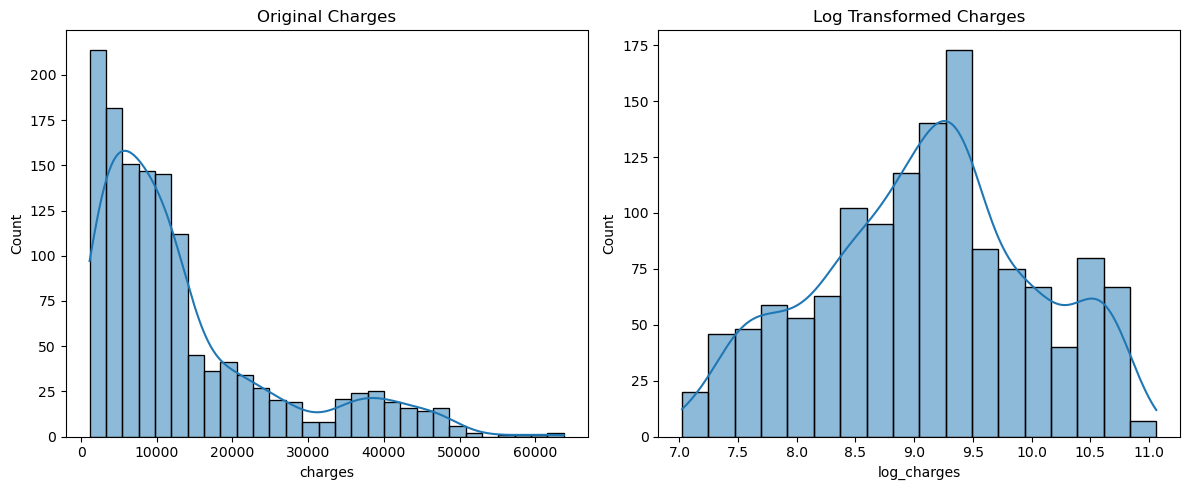

In [503]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# First histogram
sns.histplot(df["charges"], kde=True, ax=ax[0])
ax[0].set_title("Original Charges")

# Second histogram
sns.histplot(df["log_charges"], kde=True, ax=ax[1])
ax[1].set_title("Log Transformed Charges")

plt.tight_layout()
plt.show()

## Model output y vs log_y

In [504]:
log_y = df["log_charges"]

x_train,x_test,y_train,y_test = train_test_split(scalerX,log_y,test_size=0.2,random_state=93)

models = [LinearRegression(),DecisionTreeRegressor(),RandomForestRegressor(),KNeighborsRegressor(),SVR(), 
         ExtraTreesRegressor(),    GradientBoostingRegressor(),    AdaBoostRegressor(),    HistGradientBoostingRegressor()]

model_names = ["Linear Regression","Decision Tree Regressor","Random Forest Regressor",
               "K Neighbors Regressor","Support Vector Regressor","Extra Trees Regressor",    "Gradient Boosting Regressor",
    "AdaBoost Regressor",    "HistGradientBoosting Regressor" ]

metrics_result_log = []

for model, name in zip(models, model_names):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    y_pred_original = np.exp(y_pred) 
    y_test_original = np.exp(y_test)
    
    r2 = r2_score( y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    
 
    metrics_result_log.append([name, round(r2,4), round(mse,4), round(mae, 4), round(rmse, 4)])


models = [ XGBRegressor(),    LGBMRegressor(verbose=-1),    CatBoostRegressor(verbose=0)]

model_names = ["XGBoost Regressor", "LightGBM Regressor",  "CatBoost Regressor"]



for model, name in zip(models, model_names):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    y_pred_original = np.exp(y_pred) 
    y_test_original = np.exp(y_test)
    
    r2 = r2_score( y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    
 
    metrics_result_log.append([name, round(r2,4), round(mse,4), round(mae, 4), round(rmse, 4)])
   
results_log_df = pd.DataFrame(metrics_result_log, columns=["Model", "R2 Score", "MSE", "MAE", "RMSE"])

results_log_df = results_log_df.sort_values(  by="R2 Score", ascending=True)

results_log_df = results_log_df.reset_index(drop=True)
results_log_df.index = results_log_df.index + 1

results_log_df


,Model,R2 Score,MSE,MAE,RMSE
1,Linear Regression,0.4620,7.390524e+07,4097.6490,8596.8157
2,Decision Tree Regressor,0.7330,3.667307e+07,2629.9311,6055.8296
3,K Neighbors Regressor,0.8075,2.643614e+07,2823.9845,5141.6090
4,Support Vector Regressor,0.8373,2.234420e+07,2203.5566,4726.9649
5,XGBoost Regressor,0.8401,2.196500e+07,2425.5200,4686.6837
6,AdaBoost Regressor,0.8438,2.146089e+07,3339.5431,4632.5905
7,Extra Trees Regressor,0.8541,2.003530e+07,2044.6749,4476.0808
8,CatBoost Regressor,0.8616,1.901124e+07,2134.6709,4360.1883
9,LightGBM Regressor,0.8634,1.876199e+07,2134.7625,4331.5114
10,HistGradientBoosting Regressor,0.8658,1.843302e+07,2085.0947,4293.3688


There is no signicant differnce between the y and log_y then we leave it as it 

## Hyperparameter tuning of the best models

the hyperparameter tuning do not have any improvement, then its better to ignore. model already optimized

Tuning  GradientBoostingRegressor Model

In [505]:
gb = GradientBoostingRegressor(random_state=93)

In [506]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

In [507]:
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=50,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

,estimator,GradientBoost...ndom_state=93)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [508]:
print(random_search.best_params_)

{'subsample': 0.9, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}


In [509]:
print(random_search.best_score_)

0.8387758502815421


In [510]:
best_gb = random_search.best_estimator_

y_pred = best_gb.predict(x_test)

In [511]:

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.8277220126442882
MAE: 0.18355862109849147
RMSE: 0.3851553450541936


Tuning  RandomForestRegressor Model

In [512]:
rf = RandomForestRegressor(random_state=42)
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
    "bootstrap": [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(x_train, y_train)

print(rf_random_search.best_params_)

{
'n_estimators': 500,
'min_samples_split': 5,
'min_samples_leaf': 2,
'max_features': 'sqrt',
'max_depth': 20,
'bootstrap': True
}

print(rf_random_search.best_score_)

best_rf = rf_random_search.best_estimator_

y_pred = best_rf.predict(x_test)



r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 5, 'bootstrap': True}
0.8380261818446078
R²: 0.8236279377945674
MAE: 0.19095008963360785
RMSE: 0.38970495783616343
